<center><h1 style="font-size: 30px;"><b>Athens House Listings for Sale Dataset Preparation</b></h1></center>

<center><h1 style="font-size: 18px;"><b>This notebook focuses on the data processing and feature engineering phase for Athens real estate listings.</b></h1></center>

Building on the previously cleaned dataset, it implements the necessary transformations, including categorical encoding, scaling, and outlier handling, to produce a refined, analysis-ready dataset optimized for predictive modeling and market trend exploration.

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

In [2]:
# Ignore all FutureWarnings
warnings.simplefilter(action = 'ignore', category = FutureWarning)
warnings.filterwarnings('ignore')

In [3]:
# Set path to retrieve csv file
file_path = r"C:\Users\marko\Documents\Database\Athens_House_Listings\Cleaned\house_listings_dataset_cleaned.csv"

In [4]:
# Load the csv file into the df
try:
    df = pd.read_csv(file_path)
    print('Csv file successfully loaded to the dataframe!')
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Csv file successfully loaded to the dataframe!


In [5]:
# View the first rows
df.head()

,airConditioning,alarm,areaSqm,balcony,bathrooms,elevator,energyClass,fireplace,floor,furnished,...,pool,price,pricePerSqm,renovationYear,rooms,solarHeater,storage,view,yearBuilt,is_renovated
0,True,True,51,True,1.0,True,D,False,7,False,...,False,106500,2088.24,2020.0,1.0,False,False,True,1958.0,True
1,True,False,53,True,1.0,True,C,False,10,False,...,False,193000,3641.51,-1.0,1.0,True,False,True,2003.0,False
2,False,True,112,True,1.0,True,C,False,9,False,...,False,295000,2633.93,2023.0,3.0,False,False,True,1980.0,True
3,True,True,304,True,2.0,True,D,False,9,False,...,False,3500000,11513.16,2025.0,3.0,False,True,True,1937.0,True
4,True,True,195,True,3.0,True,A,False,9,False,...,False,2500000,12820.51,-1.0,3.0,False,True,True,2026.0,False


In [6]:
print('The shape of the dataset is:', df.shape)

The shape of the dataset is: (12049, 27)


With the data cleaned and deduplicated, this stage focuses on feature engineering and dataset refinement. The goal is to produce a high-fidelity dataset structured specifically for deep exploratory analysis and robust predictive modeling.

# Statistical Cleaning and Feature Binning

When analyzing real estate in a city as diverse as Athens, location plays a crucial role in appartment size. Grouping by the location column is crucial because price and price per square meter, ranges shift dramatically between different neighborhoods.

In [7]:
print(df['location'].unique())
print('Number of unique locations:', df['location'].unique().shape[0])

['Άγιος Γεώργιος (Αθήνα - Κέντρο)' 'Αμπελόκηποι (Αθήνα - Κέντρο)'
 'Κολωνάκι (Κολωνάκι - Λυκαβηττός)' 'Χίλτον (Αθήνα - Κέντρο)'
 'Πανόρμου (Αθήνα - Κέντρο)' 'Παγκράτι (Αθήνα - Κέντρο)'
 'Κέντρο Παγκρατίου (Αθήνα - Κέντρο)' 'Λυκαβηττός (Κολωνάκι - Λυκαβηττός)'
 'Βαρνάβα (Αθήνα - Κέντρο)' 'Πύργος Αθηνών (Αθήνα - Κέντρο)'
 'Αγίου Μελετίου - Πλατεία Βικτωρίας - Μάρνη (Αθήνα - Κέντρο)'
 'Πλατεία Αμερικής (Αθήνα - Κέντρο)' 'Άγιος Νικόλαος (Αθήνα - Κέντρο)'
 'Σύνταγμα (Αθήνα - Κέντρο)' 'Κυψέλη (Αθήνα - Κέντρο)'
 'Νέα Κυψέλη (Αθήνα - Κέντρο)' 'Κουκάκι - Μακρυγιάννη (Αθήνα - Κέντρο)'
 'Κουκάκι - Παιδική Χαρά (Κουκάκι - Μακρυγιάννη)'
 'Κάτω Πατήσια (Αθήνα - Κέντρο)' 'Μεταξουργείο (Αθήνα - Κέντρο)'
 'Άγιος Θωμάς (Αθήνα - Κέντρο)' 'Πλατεία Αττικής (Αθήνα - Κέντρο)'
 'Κάτω Ιλίσια (Αθήνα - Κέντρο)' 'Εξάρχεια (Αθήνα - Κέντρο)'
 'Άλσος Παγκρατίου (Αθήνα - Κέντρο)' 'Κυνοσάργους (Αθήνα - Κέντρο)'
 'Άνω Πετράλωνα (Αθήνα - Κέντρο)' 'Άγιος Ιωάννης (Αθήνα - Κέντρο)'
 'Άγιος Αρτέμιος (Αθήνα - Κέντρο)' 'Κάτω 

With **120 unique entries** in the location column, the data is currently too fragmented for meaningful outlier detection. To improve statistical significance, we will perform feature engineering to map these specific sub-localities into broader Athens districts. Consolidating these categories will allow for more robust location-based outlier identification and a cleaner visualization of market trends.

In [8]:
# Removes the specific suffix and any trailing whitespace
df['location'] = df['location'].str.replace(r' \(Αθήνα - Κέντρο\)', '', regex=True).str.strip()

In [9]:
# Verify that number of unique locations remained the same
print('Number of unique locations after string manipulation:', df['location'].unique().shape[0])

Number of unique locations after string manipulation: 120


In [10]:
print(df['location'].unique())

['Άγιος Γεώργιος' 'Αμπελόκηποι' 'Κολωνάκι (Κολωνάκι - Λυκαβηττός)'
 'Χίλτον' 'Πανόρμου' 'Παγκράτι' 'Κέντρο Παγκρατίου'
 'Λυκαβηττός (Κολωνάκι - Λυκαβηττός)' 'Βαρνάβα' 'Πύργος Αθηνών'
 'Αγίου Μελετίου - Πλατεία Βικτωρίας - Μάρνη' 'Πλατεία Αμερικής'
 'Άγιος Νικόλαος' 'Σύνταγμα' 'Κυψέλη' 'Νέα Κυψέλη' 'Κουκάκι - Μακρυγιάννη'
 'Κουκάκι - Παιδική Χαρά (Κουκάκι - Μακρυγιάννη)' 'Κάτω Πατήσια'
 'Μεταξουργείο' 'Άγιος Θωμάς' 'Πλατεία Αττικής' 'Κάτω Ιλίσια' 'Εξάρχεια'
 'Άλσος Παγκρατίου' 'Κυνοσάργους' 'Άνω Πετράλωνα' 'Άγιος Ιωάννης'
 'Άγιος Αρτέμιος' 'Κάτω Πετράλωνα' 'Σεπόλια' 'Άνω Κυψέλη' 'Νέος Κόσμος'
 'Κολωνός (Κολωνός - Κολοκυνθούς)' 'Καλλιμάρμαρο' 'Κεραμεικός'
 'Λόφος Φινοπούλου' 'Πλατεία Κυψέλης' 'Προφήτης Ηλίας' 'Πετράλωνα'
 'Πλατεία Βάθης' 'Ερυθρός' 'Ρηγίλλης (Κολωνάκι - Λυκαβηττός)'
 'Εξάρχεια - Νεάπολη' 'Πολυτεχνείο' 'Ιστορικό Κέντρο'
 'Ευελπίδων - Δικαστήρια' 'Φωκίωνος Νέγρη' 'Όσιος Λουκάς'
 'Κυπριάδου - Άνω Πατήσια' 'Άγιος Ελευθέριος' 'Κέντρο' 'Πλάκα' 'Ριζούπολη'
 'Νεάπολη Εξαρχείων' '

The raw dataset contains highly granular location tags, such as specific street names, squares, and landmarks. To improve our analysis, we must develop a **filtering function** that maps these diverse strings into 16 recognized urban neighborhoods in Athens. This consolidation allows for a more robust evaluation of price ranges and the identification of outliers at the neighborhood level.

In [11]:
# Replacing location strings for higher neighbourhood mapping accuracy
df['location'] = df['location'].replace('Κέντρο Παγκρατίου', 'Παγκράτι')
df['location'] = df['location'].replace('Κέντρο', 'Ιστορικό Κέντρο')
df['location'] = df['location'].replace('Ακαδημία Πλάτωνος (Κολωνός - Κολοκυνθούς)', 'Κολωνός - Κολοκυνθούς')
df['location'] = df['location'].replace('Σταθμός Λαρίσης (Κολωνός - Κολοκυνθούς)', 'Κολωνός - Κολοκυνθούς')
df['location'] = df['location'].replace('Γκύζη - Πεδίον Άρεως', 'Γκύζη')

# Listings in Gkazi - Metaxourgeio - Votanikos were verified that are actually in the Gkazi - Metaxourgeio area
df['location'] = df['location'].replace('Γκάζι - Μεταξουργείο - Βοτανικός', 'Γκάζι - Μεταξουργείο')

In [12]:
def map_to_neighborhood(loc):
    loc = loc.lower()

    # 1. Historic Center
    if any(x in loc for x in [
        'σύνταγμα', 'πλάκα', 'μοναστηράκι', 'ψυρρή', 'θησείο',
        'ακρόπολη', 'ιστορικό κέντρο',
        'κλαυθμώνος', 'καρύτση'
    ]):
        return 'Ιστορικό Κέντρο Αθήνας'

    # 2. Exarchia - Neapoli
    elif any(x in loc for x in [
        'εξάρχεια', 'εξαρχείων', 'πολυτεχνείο',
        'μουσείο', 'ακαδημία', 'κάνιγγος', 'νεάπολη'
    ]):
        return 'Εξάρχεια - Νεάπολη'

    # 3. Kolonaki – Lycabettus
    elif any(x in loc for x in [
        'κολωνάκι', 'λυκαβηττός', 'ρηγίλλης', 'χίλτον', 'λυκαβηττού'
    ]):
        return 'Κολωνάκι - Λυκαβηττός'

    # 4. Pangrati – Mets
    elif any(x in loc for x in [
        'παγκράτι', 'μετς', 'καλλιμάρμαρο',
        'βαρνάβα', 'παγκρατίου' , 'νεκροταφείο', 'προφήτης ηλίας'
    ]):
        return 'Παγκράτι - Μετς'

    # 5. Koukaki - Fix
    elif any(x in loc for x in [
        'κουκάκι', 'μακρυγιάννη', 'φιξ', 'φιλοπάππου'
    ]):
        return 'Κουκάκι - Φιξ'

    # 6. Petralona
    elif any(x in loc for x in [
        'πετράλωνα'
    ]):
        return 'Πετράλωνα'
        
    # 7. Botanikos – Rouf
    elif any(x in loc for x in [
        'βοτανικός', 'ρουφ'
    ]):
        return 'Βοτανικός - Ρουφ'
        
    # 8. Kerameikos – Omonoia
    elif any(x in loc for x in [
        'κεραμεικός', 'γκάζι', 'μεταξουργείο', 'ομόνοια', 'κουμουνδούρου'
    ]):
        return 'Κεραμεικός - Ομόνοια'
        
    # 9. Kypseli
    elif any(x in loc for x in [
        'κυψέλη', 'φωκίωνος', 'νέγρη', 'κυψέλης' , 'πολύγωνο', 'ευελπίδων', 'τουρκοβούνια', 'άρεως', 'γεώργιος'
    ]):
        return 'Κυψέλη'
        
    # 10. Gkyzi
    elif any(x in loc for x in [
        'γκύζη', 'άρειος', 'πάγος', 'φινοπούλου'
    ]):
        return 'Γκύζη'

    # 11. Patissia
    elif any(x in loc for x in [
        'πατήσια', 'κολιάτσου', 'νικόλαος', 'ριζούπολη', 'προμπονά', 'τρεις γέφυρες', 'ελευθέριος',
        'κυπριάδου', 'αχαρνών', 'παπαδιαμάντη', 'πατησίων', 'λουκάς', 'γκράβα', 'κλωναρίδου'
    ]):
        return 'Πατήσια'

    # 12. Sepolia – Kolonos
    elif any(x in loc for x in [
        'σεπόλια', 'κολωνός', 'πλάτωνος',
        'κολοκυνθούς', 'σκουζέ', 'θυμαράκια', 'λαρίσης'
    ]):
        return 'Σεπόλια - Κολωνός'

    # 13. Ampelokipoi – Goudi – Ilisia
    elif any(x in loc for x in [
        'αμπελόκηποι', 'πανόρμου', 'γουδή',
        'ιλίσια', 'πεντάγωνο', 'μαβίλη', 'ερυθρός',
        'παίδων', 'ιπποκράτειο', 'πύργος', 'ελληνορώσων', 'γηροκομείο', 'ζωγράφου'
    ]):
        return 'Αμπελόκηποι - Ιλίσια'

    # 14. Neos Kosmos
    elif any(x in loc for x in [
        'νέος', 'κόσμος', 'ιωάννης',
        'κυνοσάργους', 'αρτέμιος', 'σώστης'
    ]):
        return 'Νέος Κόσμος'

    # 15. Victoria Square - America Square
    if any(x in loc for x in [
        'μελετίου', 'βικτωρίας', 'μάρνη', 'αττικής', 'αττική', 'αμερικής', 'παντελεήμονας', 'λιοσίων', 'βάθης'
    ]):
        return 'Πλ. Βικτωρίας - Αμερικής'

    # Fallback
    else:
        return 'Other'

In [13]:
df.loc[:, 'neighborhood'] = df['location'].apply(map_to_neighborhood)

In [14]:
df['neighborhood'].value_counts()

neighborhood
Πατήσια                     1545
Πλ. Βικτωρίας - Αμερικής    1447
Κυψέλη                      1272
Παγκράτι - Μετς             1223
Αμπελόκηποι - Ιλίσια        1080
Νέος Κόσμος                  844
Σεπόλια - Κολωνός            839
Κολωνάκι - Λυκαβηττός        780
Εξάρχεια - Νεάπολη           629
Ιστορικό Κέντρο Αθήνας       607
Κεραμεικός - Ομόνοια         548
Κουκάκι - Φιξ                356
Πετράλωνα                    322
Γκύζη                        285
Other                        165
Βοτανικός - Ρουφ             107
Name: count, dtype: int64

There are **165 "Other"** values who didn't make it in any of the neighbourhoods, either because they were further from the Athens Center or were not located in any of the custom neighbourhoods. So these values will be dropped:

In [15]:
df = df[df['neighborhood'] != 'Other']

In [16]:
# Verify that they are removed
print(df['neighborhood'].value_counts())

neighborhood
Πατήσια                     1545
Πλ. Βικτωρίας - Αμερικής    1447
Κυψέλη                      1272
Παγκράτι - Μετς             1223
Αμπελόκηποι - Ιλίσια        1080
Νέος Κόσμος                  844
Σεπόλια - Κολωνός            839
Κολωνάκι - Λυκαβηττός        780
Εξάρχεια - Νεάπολη           629
Ιστορικό Κέντρο Αθήνας       607
Κεραμεικός - Ομόνοια         548
Κουκάκι - Φιξ                356
Πετράλωνα                    322
Γκύζη                        285
Βοτανικός - Ρουφ             107
Name: count, dtype: int64


In [17]:
# Drop initial "location" column since it has been converted to "neighbourhood"
df = df.drop(columns=['location'])

Now that we have mapped all the **120 different locations** into **15 distinct Athens urban neighborhoods**, we must clean the data of outliers.

## Scatter Plot: Total Price vs Square Meters by Neighborhood

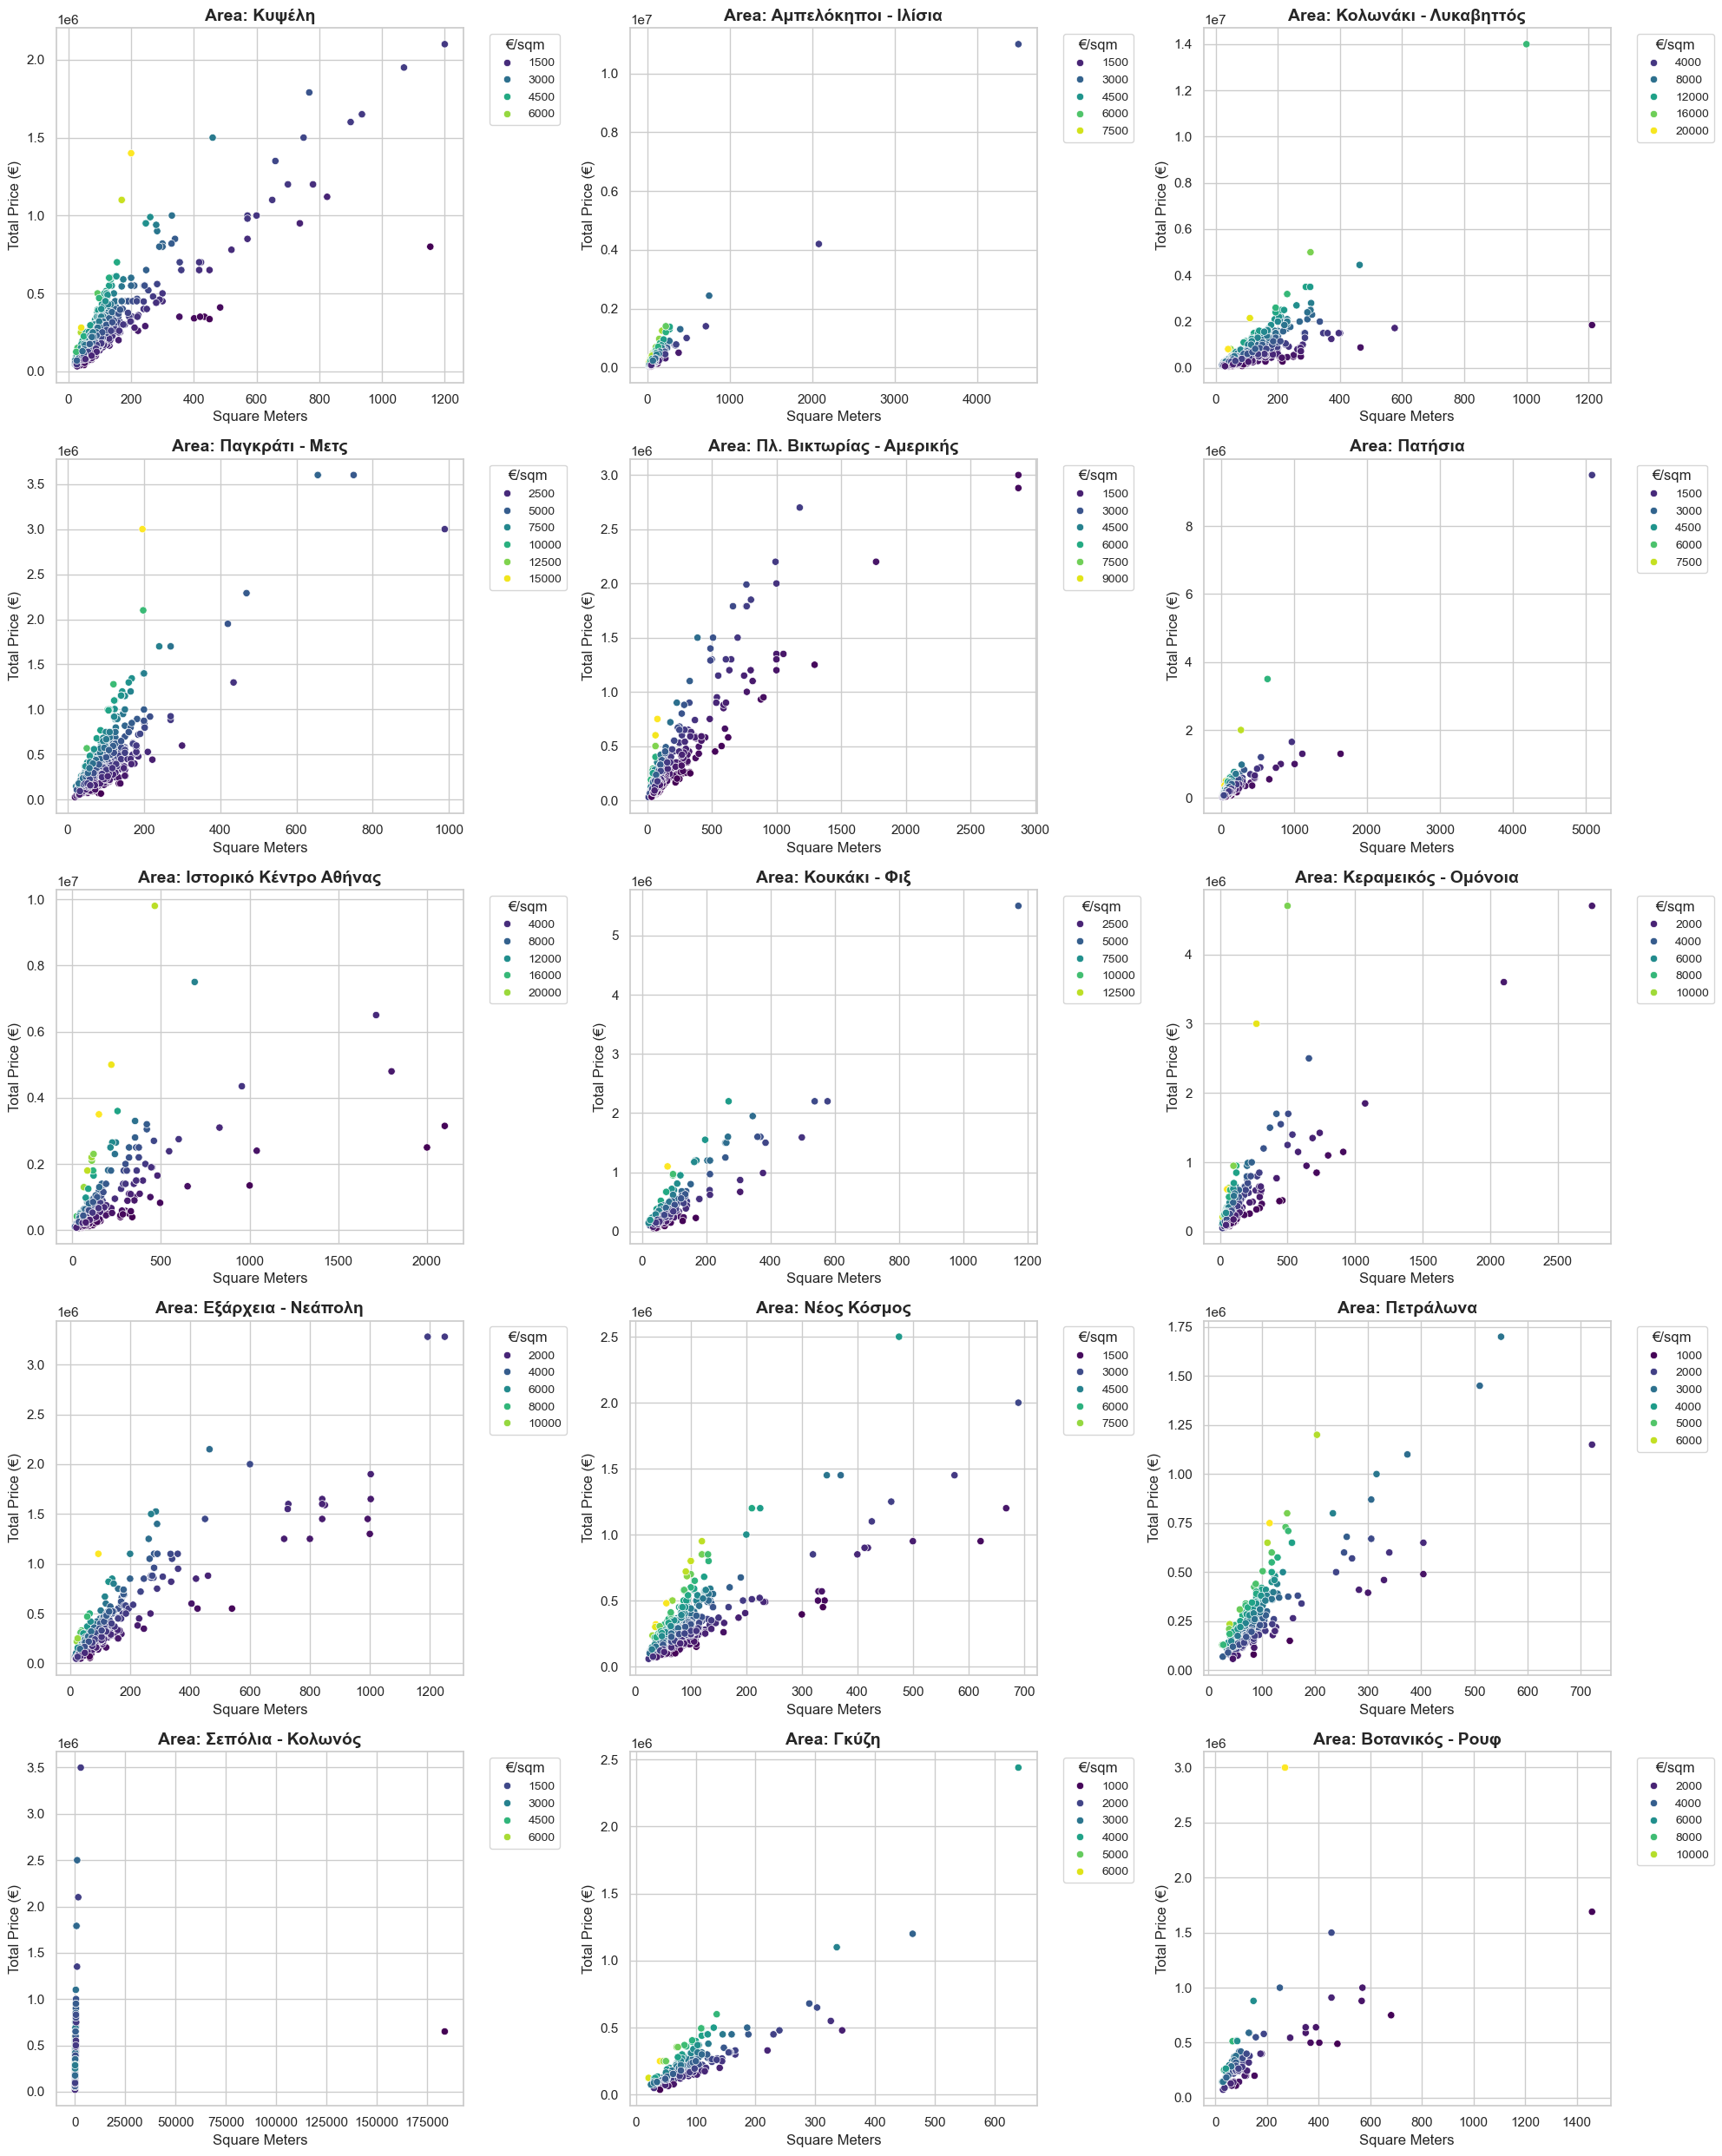

In [18]:
sns.set_theme(style="whitegrid")
neighborhoods = df['neighborhood'].unique()
n_cols = 3
n_rows = (len(neighborhoods) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, area in enumerate(neighborhoods):
    subset = df[df['neighborhood'] == area]
    
    scatter = sns.scatterplot(
        data=subset, 
        x='areaSqm', 
        y='price', 
        hue='pricePerSqm',
        palette='viridis',
        ax=axes[i]
    )
    
    axes[i].set_title(f'Area: {area}', fontweight='bold', fontsize=14)
    axes[i].set_xlabel('Square Meters')
    axes[i].set_ylabel('Total Price (€)')
    
    axes[i].legend(title='€/sqm', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- **Linear Correlation:**

Most neighborhoods (like Kypseli, Neos Kosmos, and Exarchia) show a strong, tight linear relationship. As size increases, price increases predictably.

- **Significant Outliers:**

Several plots (like Sepolia - Kolonos and Patissia) feature extreme outliers on the x-axis. For instance, the Sepolia plot shows a data point over 175,000 sqm, which is likely a data entry error or a massive industrial plot that skews the scale, making the residential data hard to read. In Spitogatos, property owners can list multiple apartments/houses or a building in one listing adding up their size, number of bathrooms, rooms etc.

- **Scale Variance:**

Note that the y-axis scales vary significantly; The Historic Center goes up to 10 million Euros, while Petralona peaks around 1.75 million, highlighting the massive disparity in "ceiling prices" across the city.

# Columns Inspection

### "areaSqm":

This section focuses on identifying listings with extreme area values. These often represent 'hidden' multi-unit listings - such as entire buildings or apartment bundles - misclassified as single residential units on the Spitogatos platform. Filtering these is essential to ensure our analysis reflects individual property market trends.

#### Why Contextual Grouping Matters

A **150m²** apartment might appear to be a statistical outlier when measured against the citywide average. However, in prestigious districts like Kolonaki or Lycabettus, such dimensions are often the baseline. Conversely, a **25m²** studio in an affordable neighborhood like Kypseli—despite being much smaller—could be a more significant outlier that warrants closer scrutiny to understand its pricing and utility within that specific market.

#### Box Plot: Square Meters by Neighborhood

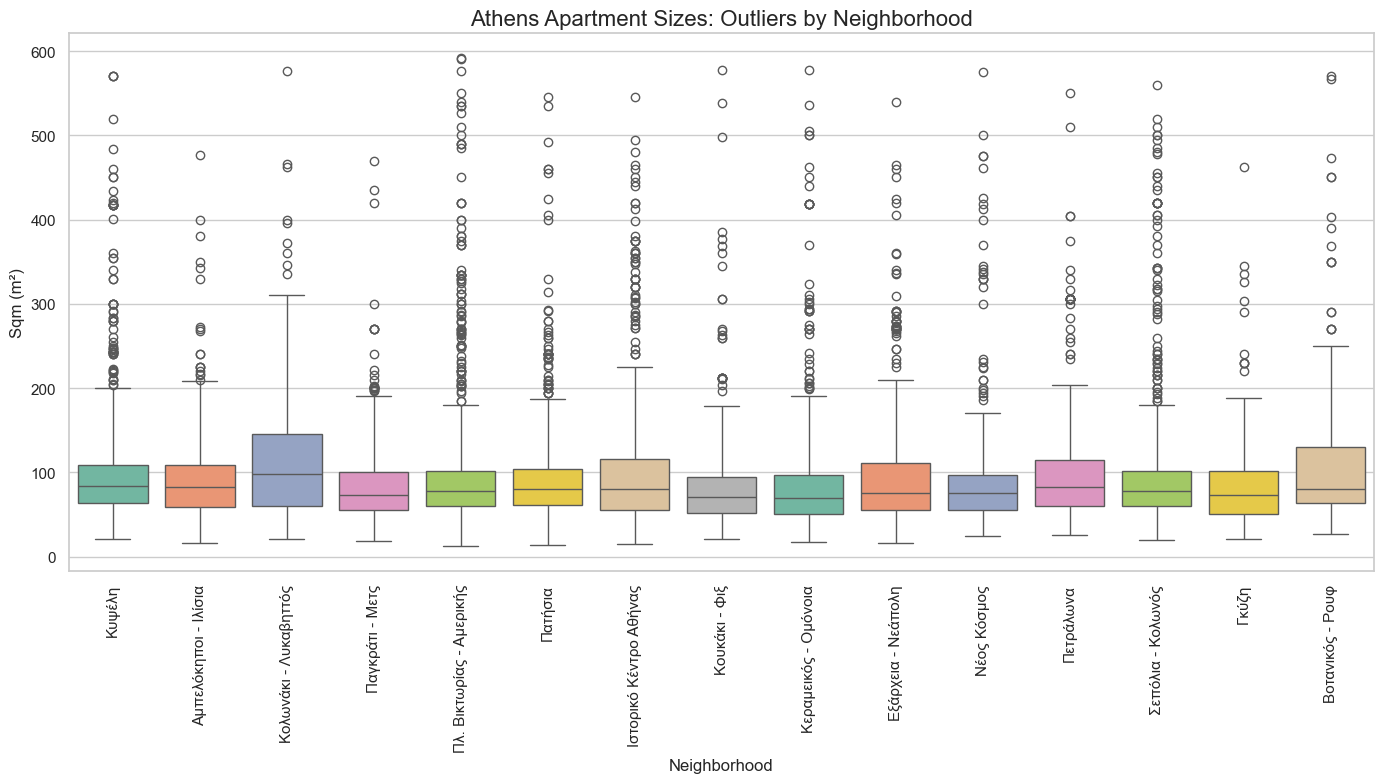

In [60]:
# Plot Data
df_plot = df[['neighborhood', 'areaSqm']]
df_plot = df[df['areaSqm'] < 600].copy()

# Create the Boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_plot, x='neighborhood', y='areaSqm', palette='Set2', whis=1.5)

plt.xticks(rotation=90) # Rotates location names so they don't overlap
plt.title('Athens Apartment Sizes: Outliers by Neighborhood', fontsize=16)
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Sqm (m²)', fontsize=12)

plt.tight_layout()
plt.show()

Because we have a **skewed distribution**, we will identify outliers by calculating the **Interquartile Range (IQR)** of each neighborhood.

We will develop a function to remove outliers and produce a **clean dataframe**.

In [20]:
def remove_neighborhood_outliers_sqm(df, column='areaSqm'):

    cleaned_groups = []
    

    for neighborhood, group in df.groupby('neighborhood'):

        Q1 = group[column].quantile(0.25)
        Q3 = group[column].quantile(0.75)
        IQR = Q3 - Q1
        
        # Define bounds
        lower_bound = max(15, Q1 - 1.5 * IQR)
        upper_bound = Q3 + 1.5 * IQR
        
        filtered_group = group[(group[column] >= lower_bound) & (group[column] <= upper_bound)]
        cleaned_groups.append(filtered_group)
    
    # Combine everything back into one dataframe
    return pd.concat(cleaned_groups, ignore_index=True)

In [21]:
# Apply the function
df_clean = remove_neighborhood_outliers_sqm(df, column='areaSqm')

In [22]:
# Verification
print('Original rows:',len(df))
print('Rows after IQR cleaning:', len(df_clean))

Original rows: 11884
Rows after IQR cleaning: 11033


Using the **Interquartile Range (IQR)** method, we identified properties exceeding ($Q3 + 1.5 \times IQR$) as statistical outliers. These listings were excluded from the analysis to maintain data homogeneity, as their scale deviates from the standard urban apartment profile and would otherwise skew the results.

Because the **IQR** calculation ($Q1 - 1.5 \times IQR$) yields a negative value, we manually adjusted the lower limit to $15\text{ m}^2$ to reflect realistic apartment sizes.

We will implement a function to isolate and return a filtered dataframe containing only the identified outliers for further analysis.

In [23]:
def get_neighborhood_outliers_sqm(df, column='areaSqm'):

    outlier_groups = []
    
    for neighborhood, group in df.groupby('neighborhood'):
        Q1 = group[column].quantile(0.25)
        Q3 = group[column].quantile(0.75)
        IQR = Q3 - Q1
        
        # Define bounds
        lower_bound = max(15, Q1 - 1.5 * IQR)
        upper_bound = Q3 + 1.5 * IQR
        
        # Filter for data OUTSIDE the bounds
        outliers = group[(group[column] < lower_bound) | (group[column] > upper_bound)]
        
        outlier_groups.append(outliers)
    
    # Combine all outlier rows into one dataframe
    return pd.concat(outlier_groups, ignore_index=True)

In [24]:
# Apply the function
df_outliers_sqm = get_neighborhood_outliers_sqm(df, column='areaSqm')

In [25]:
# Verification
print('Original rows:',len(df))
print('Number of outliers detected:', len(df_outliers_sqm))

Original rows: 11884
Number of outliers detected: 851


### "pricePerSqm":

With the areaSqm and price columns cleaned and outliers removed, our next step is to analyze the pricePerSqm for apartments in Central Athens. This metric is vital for our subsequent analysis, as it allows us to identify high-value properties relative to their specific dimensions.

#### Why Contextual Grouping Matters

A listing priced at **6,500€/m²** might seem like a massive statistical outlier when compared to the Athens city average. However, in a high-end district like Kolonaki, that figure is often the standard baseline for well-maintained properties. Conversely, a studio in Kypseli priced at **4,000€/m²** would be a significant outlier requiring investigation; even though its total price is lower than a Kolonaki home, its price per square meter is nearly double the neighborhood norm of approximately **2,100€/m²**.

#### Box Plot: Price per Sqm by Neighborhood

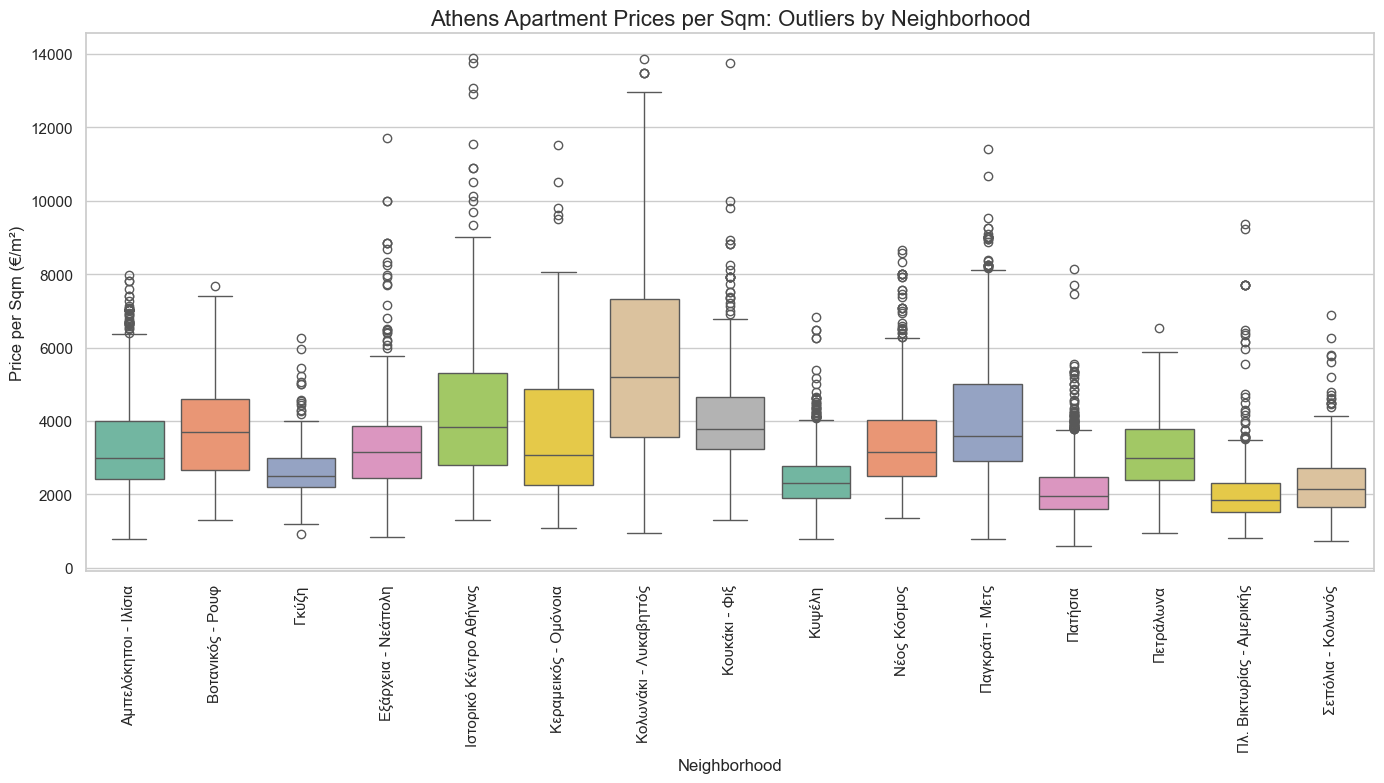

In [26]:
df_plot = df_clean[['neighborhood', 'pricePerSqm']]
df_plot = df_clean[df_clean['pricePerSqm'] < 15000].copy()

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_plot, x='neighborhood', y='pricePerSqm', palette='Set2', whis=1.5)

plt.xticks(rotation=90)
plt.title('Athens Apartment Prices per Sqm: Outliers by Neighborhood', fontsize=16)
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Price per Sqm (€/m²)', fontsize=12)

plt.tight_layout()
plt.show()

While the boxplot shows values **below 1,000€/m²**, these are increasingly considered **"data noise"** in 2026. They typically represent properties with major legal issues, undivided shares, or semi-basement units in poor condition that do not reflect the habitable market. To ensure the integrity of our analysis, we must adjust the lower bounds for each neighborhood to filter out these extreme low-end anomalies and produce a more accurate dataset.

In this case, detecting outliers with IQR and custom limits for pricePerSqm will result to a more aqqurate dataset

We will develop a function, with a dictionary containing custom made lower bounds for each neighbourhood, to remove outliers and produce a **refined dataframe**.

In [27]:
def remove_neighborhood_outliers_pricepersqm(df, column='pricePerSqm'):
    # Define the custom lower bounds for each neighborhood
    custom_lower_limits = {
        'Αμπελόκηποι - Ιλίσια': 1600.0,
        'Βοτανικός - Ρουφ': 1200.0,
        'Κεραμεικός - Ομόνοια': 1600.0,
        'Γκύζη': 1100.0,
        'Εξάρχεια - Νεάπολη': 1500.0,
        'Ιστορικό Κέντρο Αθήνας': 2800.0,
        'Κολωνάκι - Λυκαβηττός': 3000.0,
        'Κουκάκι - Φιξ': 2200.0,
        'Κυψέλη': 1100.0,
        'Νέος Κόσμος': 1700.0,
        'Παγκράτι - Μετς': 1800.0,
        'Πατήσια': 900.0,
        'Πετράλωνα': 1900.0,
        'Πλ. Βικτωρίας - Αμερικής': 850.0,
        'Σεπόλια - Κολωνός': 850.0
    }

    # Define the custom upper bounds for each neighborhood
    custom_upper_limits = {
        'Αμπελόκηποι - Ιλίσια': 4200.0,
        'Βοτανικός - Ρουφ': 3500.0,
        'Κεραμεικός - Ομόνοια': 4800.0,
        'Γκύζη': 3200.0,
        'Εξάρχεια - Νεάπολη': 4800.0,
        'Ιστορικό Κέντρο Αθήνας': 10000.0,
        'Κολωνάκι - Λυκαβηττός': 12000.0,
        'Κουκάκι - Φιξ': 7000.0,
        'Κυψέλη': 3500.0,
        'Νέος Κόσμος': 4500.0,
        'Παγκράτι - Μετς': 5500.0,
        'Πατήσια': 2800.0,
        'Πετράλωνα': 5000.0,
        'Πλ. Βικτωρίας - Αμερικής': 2600.0,
        'Σεπόλια - Κολωνός': 2500.0
    }

    cleaned_groups = []
    
    for neighborhood, group in df.groupby('neighborhood'):
        # Calculate standard IQR bounds
        Q1 = group[column].quantile(0.25)
        Q3 = group[column].quantile(0.75)
        IQR = Q3 - Q1
        
        # Get the custom limits
        nb_min = custom_lower_limits.get(neighborhood, 0)
        nb_max = custom_upper_limits.get(neighborhood, float('inf'))
        
        # Calculate final bounds:
        lower_bound = max(nb_min, Q1 - 2.5 * IQR)
        
        upper_bound = min(nb_max, Q3 + 2.5 * IQR)
        
        filtered_group = group[(group[column] >= lower_bound) & (group[column] <= upper_bound)]
        cleaned_groups.append(filtered_group)
    
    return pd.concat(cleaned_groups, ignore_index=True)

In [28]:
df_refined = remove_neighborhood_outliers_pricepersqm(df_clean, column='pricePerSqm')

In [29]:
print('Original rows:',len(df_clean))
print('Rows after IQR cleaning:', len(df_refined))

Original rows: 11033
Rows after IQR cleaning: 8946


We will implement a function to isolate and return a filtered dataframe containing only the identified outliers for further analysis.

In [30]:
def get_neighborhood_outliers_pricepersqm(df, column='pricePerSqm'):

    custom_lower_limits = {
        'Αμπελόκηποι - Ιλίσια': 1600.0,
        'Βοτανικός - Ρουφ': 1200.0,
        'Κεραμεικός - Ομόνοια': 1600.0,
        'Γκύζη': 1100.0,
        'Εξάρχεια - Νεάπολη': 1500.0,
        'Ιστορικό Κέντρο Αθήνας': 2800.0,
        'Κολωνάκι - Λυκαβηττός': 3000.0,
        'Κουκάκι - Φιξ': 2200.0,
        'Κυψέλη': 1100.0,
        'Νέος Κόσμος': 1700.0,
        'Παγκράτι - Μετς': 1800.0,
        'Πατήσια': 900.0,
        'Πετράλωνα': 1900.0,
        'Πλ. Βικτωρίας - Αμερικής': 850.0,
        'Σεπόλια - Κολωνός': 850.0
    }

    custom_upper_limits = {
        'Αμπελόκηποι - Ιλίσια': 4200.0,
        'Βοτανικός - Ρουφ': 3500.0,
        'Κεραμεικός - Ομόνοια': 4800.0,
        'Γκύζη': 3200.0,
        'Εξάρχεια - Νεάπολη': 4800.0,
        'Ιστορικό Κέντρο Αθήνας': 10000.0,
        'Κολωνάκι - Λυκαβηττός': 12000.0,
        'Κουκάκι - Φιξ': 7000.0,
        'Κυψέλη': 3500.0,
        'Νέος Κόσμος': 4500.0,
        'Παγκράτι - Μετς': 5500.0,
        'Πατήσια': 2800.0,
        'Πετράλωνα': 5000.0,
        'Πλ. Βικτωρίας - Αμερικής': 2600.0,
        'Σεπόλια - Κολωνός': 2500.0
    }

    outlier_groups = []
    
    for neighborhood, group in df.groupby('neighborhood'):
        Q1 = group[column].quantile(0.25)
        Q3 = group[column].quantile(0.75)
        IQR = Q3 - Q1

        nb_min = custom_lower_limits.get(neighborhood, 0)
        nb_max = custom_upper_limits.get(neighborhood, float('inf'))
        
        lower_bound = max(nb_min, Q1 - 2.5 * IQR)
        
        upper_bound = min(nb_max, Q3 + 2.5 * IQR)
        
        # Filter for data OUTSIDE the bounds
        outliers = group[(group[column] < lower_bound) | (group[column] > upper_bound)]
        
        outlier_groups.append(outliers)
    
    # Combine all outlier rows into one dataframe
    if not outlier_groups:
        return pd.DataFrame(columns=df.columns)
        
    return pd.concat(outlier_groups, ignore_index=True)

In [31]:
df_outliers_pricepersqm = get_neighborhood_outliers_pricepersqm(df_clean, column='pricePerSqm')

In [32]:
print('Original rows:',len(df_clean))
print('Number of outliers detected:', len(df_outliers_pricepersqm))

Original rows: 11033
Number of outliers detected: 2087


We must also create an outliers dataset, containing **only** the ones with **high prices per sqm**.

In [33]:
def get_neighborhood_upper_outliers_high_end(df, column='pricePerSqm'):

    custom_upper_limits = {
        'Αμπελόκηποι - Ιλίσια': 4200.0,
        'Βοτανικός - Ρουφ': 3500.0,
        'Κεραμεικός - Ομόνοια': 4800.0,
        'Γκύζη': 3200.0,
        'Εξάρχεια - Νεάπολη': 4800.0,
        'Ιστορικό Κέντρο Αθήνας': 10000.0,
        'Κολωνάκι - Λυκαβηττός': 12000.0,
        'Κουκάκι - Φιξ': 7000.0,
        'Κυψέλη': 3500.0,
        'Νέος Κόσμος': 4500.0,
        'Παγκράτι - Μετς': 5500.0,
        'Πατήσια': 2800.0,
        'Πετράλωνα': 5000.0,
        'Πλ. Βικτωρίας - Αμερικής': 2600.0,
        'Σεπόλια - Κολωνός': 2500.0
    }

    outlier_groups = []
    
    for neighborhood, group in df.groupby('neighborhood'):

        Q1 = group[column].quantile(0.25)
        Q3 = group[column].quantile(0.75)
        IQR = Q3 - Q1
        
        nb_max = custom_upper_limits.get(neighborhood, float('inf'))

        upper_bound = min(nb_max, Q3 + 2.5 * IQR)
        
        outliers = group[group[column] > upper_bound]
        
        outlier_groups.append(outliers)
    
    if not outlier_groups:
        return pd.DataFrame(columns=df.columns)
        
    return pd.concat(outlier_groups, ignore_index=True)

In [34]:
df_outliers_pricepersqm_high_end = get_neighborhood_upper_outliers_high_end(df_clean, column='pricePerSqm')

In [35]:
print('Number of rows in df_outliers:', len(df_outliers_pricepersqm_high_end))

Number of rows in df_outliers: 1711


## Scatter Plot: Total Price vs Square Meters by Neighborhood

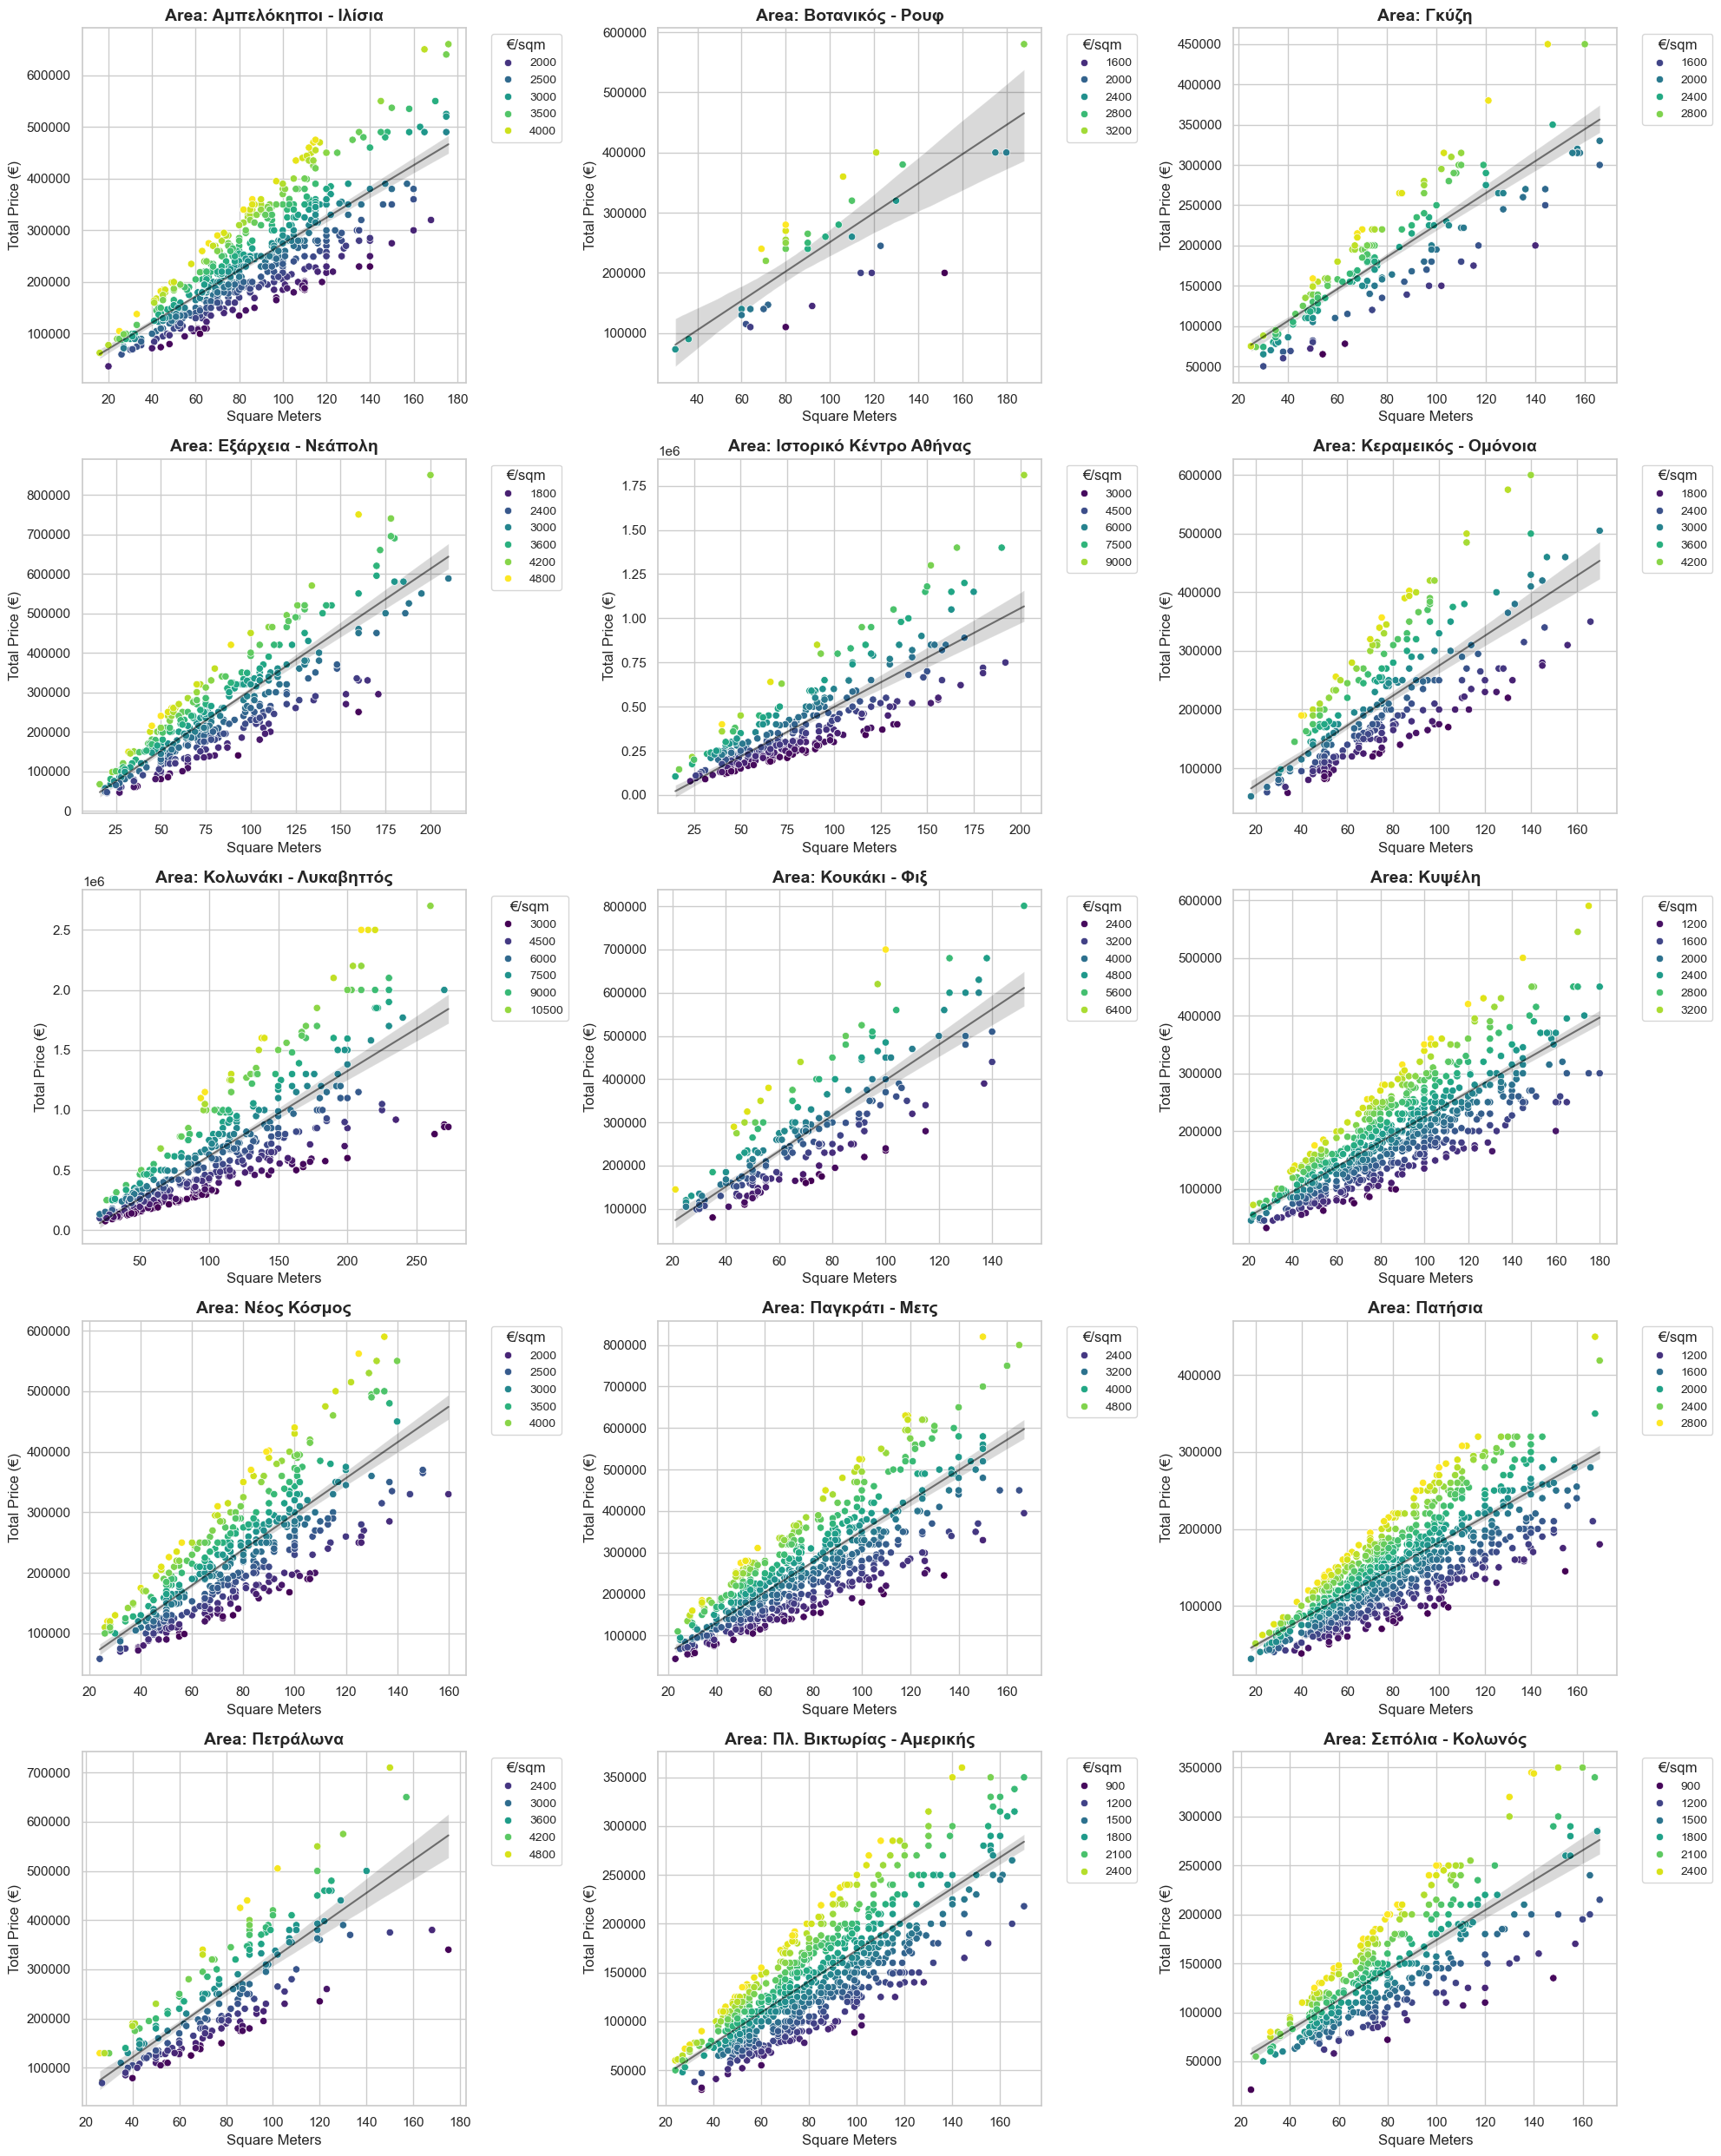

In [36]:
sns.set_theme(style="whitegrid")
neighborhoods = df_refined['neighborhood'].unique()
n_cols = 3
n_rows = (len(neighborhoods) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, area in enumerate(neighborhoods):
    subset = df_refined[df_refined['neighborhood'] == area]
    
    sns.regplot(
        data=subset, 
        x='areaSqm', 
        y='price', 
        scatter=False,
        ax=axes[i], 
        color='black',
        line_kws={"linewidth": 1.5, "alpha": 0.5}
    )
    
    sns.scatterplot(
        data=subset, 
        x='areaSqm', 
        y='price', 
        hue='pricePerSqm', 
        palette='viridis', 
        ax=axes[i]
    )
    
    axes[i].set_title(f'Area: {area}', fontweight='bold', fontsize=14)
    axes[i].set_xlabel('Square Meters')
    axes[i].set_ylabel('Total Price (€)')
    
    # Clean up the legend
    axes[i].legend(title='€/sqm', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- **Premium Areas:**

Kolonaki - Lycabettus and the Historic Center show much steeper slopes. Even for smaller apartments, prices frequently climb toward 500.000€–1.000.000€. The €/sqm legend for Kolonaki goes up to 12,500, the highest in the set.

- **Price Variance:**

There is tight correlation in areas like Neos Kosmos and Gyzi, the dots ascend closely to the regression line. This suggests very predictable pricing based on size.

In the Historic Center and Exarcheia, the dots are more scattered (high variance). This implies that factors other than size, such as a view of the Acropolis or floor level or whether the unit is renovated, drastically impact the price.

- **Data Consistency:**

The cleaning strategy we applied successfully addressed the horizontal and vertical outliers. Now all neighborhoods is now logically capped, making the charts actually usable for market analysis.

# Structural and Logical Checks

In this section we will identify listings with unrealistic characteristics that might have made it through our outlier detection and cleaning, and drop them.

### "bathrooms":

In [37]:
df_refined['bathrooms'].value_counts()

bathrooms
1.0    7628
2.0    1183
3.0     108
4.0      25
5.0       2
Name: count, dtype: int64

We will keep listings with with **maximum 3 bathrooms**.

In [38]:
df_refined = df_refined[df_refined['bathrooms'] < 4]
print('The max number of bathrooms in a house is now',df_refined['bathrooms'].max())

The max number of bathrooms in a house is now 3.0


### "kitchens":

In [39]:
df_refined['kitchens'].value_counts()

kitchens
1.0     8760
2.0      133
3.0       17
7.0        1
4.0        1
11.0       1
8.0        1
9.0        1
13.0       1
5.0        1
16.0       1
12.0       1
Name: count, dtype: int64

We will keep listings with with **maximum 2 kitchens**.

In [40]:
df_refined = df_refined[df_refined['kitchens'] < 3]
print('The max number of kitchens in a house is now',df_refined['kitchens'].max())

The max number of kitchens in a house is now 2.0


### "livingRooms":

In [41]:
df_refined['livingRooms'].value_counts()

livingRooms
1.0     8570
2.0      291
3.0       28
4.0        2
41.0       1
5.0        1
Name: count, dtype: int64

We will keep listings with with **maximum 3 living rooms**.

In [42]:
df_refined = df_refined[df_refined['livingRooms'] < 4]
print('The max number of living rooms in a house is now',df_refined['livingRooms'].max())

The max number of living rooms in a house is now 3.0


### "rooms":

In [43]:
df_refined['rooms'].value_counts()

rooms
2.0     4322
1.0     2768
3.0     1581
4.0      192
5.0       19
6.0        6
56.0       1
Name: count, dtype: int64

We will keep listings with with **maximum 6 rooms**.

In [44]:
df_refined = df_refined[df_refined['rooms'] < 7]
print('The max number of rooms in a house is now',df_refined['rooms'].max())

The max number of rooms in a house is now 6.0


### "yearBuilt":

In [45]:
df_refined['yearBuilt'].unique()

array([2003., 1980., 2155., 1970., 2025., 1960., 1972., 1981., 1965.,
       2011., 1968., 1969., 1979., 2024., 1967., 1978., 2005., 1976.,
       1964., 1962., 1975., 2012., 1988., 1966., 1971., 1959., 2008.,
       1973., 2026., 2007., 1961., 2002., 1957., 1930., 1977., 1963.,
       2010., 1950., 1974., 2027., 1939., 1993., 1958., 1936., 1995.,
       2000., 1956., 1955., 1992., 1982., 1994., 1990., 2004., 2023.,
       1948., 1951., 1985., 2006., 2020., 1991., 1949., 1952., 1987.,
       1989., 2019., 1999., 1983., 2001., 1940., 1920., 1984., 1925.,
       1998., 2009., 1954., 1945., 1927., 1935., 1934., 1937., 1900.,
       1938., 1942., 1111., 1953., 1946., 1997., 1922., 1910., 1924.,
       1933., 2022., 1907., 1901., 1996., 2018., 1915., 1691., 1986.,
       1932., 1941., 1947., 2013., 2021., 2016., 2017., 2015., 1928.,
       2014., 1067., 1944.])

The yearBuilt column contains several noteworthy anomalies. Data entry appears inconsistent, featuring historical outliers dating back to 1198 and the early 20th century. Additionally, there are logical inconsistencies with 'future' dates, such as 2028 or 2155, which exceed the current calendar year.

We will assume that the values exceeding the current year, are houses under construction. For example, 2028 might be the estimated year the construction will be finished. These houses must be analyzed further to validate this hypothesis. In this notebook we will not pay attention to these house listings as they will not take part in the final analysis.

We will only keep listings of houses built from **1950 to 2026**.

In [46]:
df_refined = df_refined[(df_refined['yearBuilt'] >= 1950) & (df_refined['yearBuilt'] <= 2026)]

In [47]:
print('Number of listings built between 1950 and 2026:', df_refined.shape[0])

Number of listings built between 1950 and 2026: 8547


# Final Dataset Validation

In [50]:
# View duplicate values in both datasets that might have been created during the cleaning process
print('Number of duplicates in df_refined:', df_refined.duplicated().sum())
print('Number of duplicates in df_outliers_pricepersqm:', df_outliers_pricepersqm.duplicated().sum())
print('Number of duplicates in df_outliers_pricepersqm_high_end:', df_outliers_pricepersqm_high_end.duplicated().sum())

Number of duplicates in df_refined: 14
Number of duplicates in df_outliers_pricepersqm: 10
Number of duplicates in df_outliers_pricepersqm_high_end: 9


In [51]:
# Drop duplicates in each dataset
df_refined = df_refined.drop_duplicates()
df_outliers_pricepersqm = df_outliers_pricepersqm.drop_duplicates()
df_outliers_pricepersqm_high_end = df_outliers_pricepersqm_high_end.drop_duplicates()

In [52]:
# Validate
print('Number of duplicates in df_refined after removal:', df_refined.duplicated().sum())
print('Number of duplicates in df_outliers_pricepersqm after removal:', df_outliers_pricepersqm.duplicated().sum())
print('Number of duplicates in df_outliers_pricepersqm_high_end after removal:', df_outliers_pricepersqm_high_end.duplicated().sum())

Number of duplicates in df_refined after removal: 0
Number of duplicates in df_outliers_pricepersqm after removal: 0
Number of duplicates in df_outliers_pricepersqm_high_end after removal: 0


# Datasets Exportation

With the dataset now refined, statistically validated, and aligned with current market criteria, we are ready to export the final version and begin our analysis.

We will also export the dataset containing the outliers we captured from the initial dataset.

In [53]:
print('The df_refined dataset has', df_refined.shape[0],'rows and', df_refined.shape[1],'columns.')
print('The df_outliers_pricepersqm dataset has', df_outliers_pricepersqm.shape[0],'rows and', df_outliers_pricepersqm.shape[1],'columns.')
print('The df_outliers_pricepersqm_high_end dataset has', df_outliers_pricepersqm_high_end.shape[0],'rows and', df_outliers_pricepersqm_high_end.shape[1],'columns.')

The df_refined dataset has 8533 rows and 27 columns.
The df_outliers_pricepersqm dataset has 2077 rows and 27 columns.
The df_outliers_pricepersqm_high_end dataset has 1702 rows and 27 columns.


In [54]:
path_for_refined = r"C:\Users\marko\Documents\Database\Athens_House_Listings\Cleaned\house_listings_dataset_refined.csv"
path_for_outliers = r"C:\Users\marko\Documents\Database\Athens_House_Listings\Cleaned\house_listings_dataset_outliers.csv"
path_for_outliers_high_end = r"C:\Users\marko\Documents\Database\Athens_House_Listings\Cleaned\house_listings_dataset_outliers_high_end.csv"

In [55]:
df_refined.to_csv(path_for_refined, encoding='utf-8-sig', index=False)

In [56]:
df_outliers_pricepersqm.to_csv(path_for_outliers, encoding='utf-8-sig', index=False)

In [57]:
df_outliers_pricepersqm_high_end.to_csv(path_for_outliers_high_end, encoding='utf-8-sig', index=False)